# Experiments

This section contains the experiments and analyses **below** “Abnormal signal session results”.
- Paths are standardized.
- Duplicated/unused code blocks were removed.
- Results are saved under `../rus/02_biomarker_spearman_correlations/` by default.


## Setup

In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from scipy.stats import spearmanr
from src.datasets.biosignal_dataset import BioSignalDataset

SEED = 42
np.random.seed(SEED)

# project paths (notebook is assumed to be in repo root or under notebooks/)
NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR if (NB_DIR / "src").exists() else NB_DIR.parent

DATA_DIR = (REPO_ROOT / "data").resolve()          # ../data
RUNS_DIR = (REPO_ROOT / "runs" / "02_biomarker_spearman_correlations").resolve()

RUNS_DIR.mkdir(parents=True, exist_ok=True)
print("REPO_ROOT:", REPO_ROOT)
print("DATA_DIR :", DATA_DIR)
print("RUNS_DIR :", RUNS_DIR)

REPO_ROOT: <REPO_ROOT>
DATA_DIR : <REPO_ROOT>/data
RUNS_DIR : <REPO_ROOT>/runs/02_biomarker_spearman_correlations


## Input files (expected)

Required:
- `../data/alcohol_Qscores.csv`

In [2]:
# Resolve key input paths (fail fast with helpful messages)
Q_CSV = DATA_DIR / "alcohol_Qscores.csv"

if not Q_CSV.exists():
    raise FileNotFoundError(f"Missing: {Q_CSV}")


## Load data

In [3]:
split_data_dir = r'/path/to/split_data/alcohol'
subject_list = os.listdir(split_data_dir)

alcohol_data = BioSignalDataset(split_data_dir, 'ECG', 'PPG', 'GSR')

raw_data_dict = alcohol_data.get_raw_data(load_pkl=r'../save/raw_data.pkl', save_pkl=r'../save/raw_data.pkl')
preprocessed_data_dict = alcohol_data.get_preprocessed_data(load_pkl=r'../save/preprocessed_data.pkl', save_pkl=r'../save/preprocessed_data.pkl')
features = alcohol_data.get_features(load_pkl=r'../save/features.pkl', save_pkl=r'../save/features.pkl')
# labels = alcohol_data.get_labels(r"../data/labels/alcohol.json")

sampling_rate_error = {"1_1_030_V1", "1_1_031_V1", "1_1_032_V1", "1_1_033_V1"}
missing_LA_RA = {"1_1_009_V1", "1_1_023_V2", "1_1_034_V1", "1_1_034_V2"}.union(sampling_rate_error)
missing_LL_LA = {"1_1_022_V2", "1_1_034_V1", "1_1_034_V2"}.union(sampling_rate_error)
missing_LL_RA = set().union(sampling_rate_error)
missing_Vx_RL = {"1_2_013_V1"}.union(sampling_rate_error)
missing_PPG = {"1_1_001_V1", "1_1_001_V2", "1_1_006_V2", "1_1_009_V1", "1_1_009_V2", "1_1_016_V2"}
missing_GSR = {
    "1_1_002_V1", "1_1_002_V2", "1_1_005_V1", "1_1_005_V2", "1_1_010_V1",
    "1_1_011_V1", "1_1_012_V2", "1_1_013_V2", "1_1_016_V1", "1_1_016_V2",
    "1_1_017_V1", "1_1_017_V2", "1_1_018_V2", "1_1_019_V1", "1_1_020_V2",
    "1_1_024_V1", "1_1_024_V2", "1_1_025_V2", "1_1_027_V2", "1_1_029_V1",
    "1_1_029_V2", "1_1_032_V2", "1_1_035_V1", "1_1_035_V2", "1_1_037_V1",
    "1_2_002_V2", "1_2_005_V1", "1_2_005_V2", "1_2_006_V1", "1_2_006_V2",
    "1_2_008_V2", "1_2_009_V1", "1_2_013_V1"
}

In [4]:
ECG_LEADS = ["LA_RA", "LL_LA", "LL_RA", "Vx_RL"]

def _is_number(x):
    return isinstance(x, (int, float, np.number)) and not isinstance(x, (bool, np.bool_))

def _safe_float(x):
    try:
        v = float(x)
        return v if np.isfinite(v) else np.nan
    except Exception:
        return np.nan

def _mean_ignore_nan(values):
    vals = [v for v in values if np.isfinite(v)]
    return float(np.mean(vals)) if len(vals) > 0 else np.nan

def _get_missing_flags(session_id, missing_sets: dict):
    flags = {}
    for k, s in missing_sets.items():
        flags[k] = session_id in s
    return flags

def _is_gsr_key(k: str) -> bool:
    ku = k.upper()
    return (
        ku.startswith("EDA") or
        "SCR" in ku or
        ku.startswith("NK_EDA") or
        ku.startswith("NK_SCR") or
        "GSR" in ku
    )

def _series_from_obj(obj):
    """PTT/HRV 등 value가 dict/Series/DataFrame(1row)일 수 있어 통일."""
    if obj is None:
        return None
    if isinstance(obj, pd.DataFrame):
        if len(obj) == 0:
            return None
        return obj.iloc[0]
    if isinstance(obj, pd.Series):
        return obj
    if isinstance(obj, dict):
        return pd.Series(obj)
    return None

def flatten_features_to_row(
    tfeat: dict,
    session_id: str,
    meta: dict,
    missing_sets: dict,
):
    """
    - ECG lead 평균: HR/RR/SI + HRV(col-wise)
    - PTT: lead별 DataFrame/Series/dict를 "컬럼 단위로" 평균 -> row["PTT_ECG_<col>"]
          (즉 mean/std 뿐 아니라 추가된 모든 PTT feature 컬럼이 들어감)
    - missing_GSR면 EDA/GSR 계열은 NaN
    """
    row = {}
    row.update(meta)
    row["session_id"] = session_id

    # ---- missing flags ----
    flags = _get_missing_flags(session_id, missing_sets)
    row.update(flags)

    miss_gsr = flags.get("missing_GSR", False)
    miss_ppg = flags.get("missing_PPG", False)

    miss_lead = {
        "LA_RA": flags.get("missing_LA_RA", False),
        "LL_LA": flags.get("missing_LL_LA", False),
        "LL_RA": flags.get("missing_LL_RA", False),
        "Vx_RL": flags.get("missing_Vx_RL", False),
    }

    # -----------------------------
    # 1) ECG HR: lead 평균 + PPG HR
    # -----------------------------
    if "HR" in tfeat and isinstance(tfeat["HR"], dict):
        hr_dict = tfeat["HR"]
        ecg_vals = []
        for lead in ECG_LEADS:
            if miss_lead[lead]:
                continue
            ecg_vals.append(_safe_float(hr_dict.get(lead, np.nan)))
        row["ECG_HR"] = _mean_ignore_nan(ecg_vals)
        row["PPG_HR"] = np.nan if miss_ppg else _safe_float(hr_dict.get("ppg", np.nan))

    # -----------------------------
    # 2) ECG HRV: lead별 동일 컬럼을 col-wise 평균
    # -----------------------------
    if "HRV" in tfeat and isinstance(tfeat["HRV"], dict):
        hrv_dict = tfeat["HRV"]  # lead -> df(1row) or dict

        lead_series = {}
        for lead in ECG_LEADS:
            if miss_lead[lead]:
                continue
            s = _series_from_obj(hrv_dict.get(lead, None))
            if s is not None:
                lead_series[lead] = s

        all_cols = set()
        for s in lead_series.values():
            all_cols |= set(s.index.tolist())

        for col in sorted(all_cols):
            vals = []
            for s in lead_series.values():
                vals.append(_safe_float(s.get(col, np.nan)))
            row[f"ECG_{col}"] = _mean_ignore_nan(vals)

        # PPG HRV (존재할 때만, miss_ppg면 NaN)
        if "ppg" in hrv_dict:
            s = _series_from_obj(hrv_dict.get("ppg", None))
            if s is not None:
                for col, v in s.items():
                    row[f"PPG_{col}"] = np.nan if miss_ppg else _safe_float(v)

    # -----------------------------
    # 3) RR / SI: lead 평균 + PPG 값
    # -----------------------------
    for key in ["RR", "SI"]:
        if key in tfeat and isinstance(tfeat[key], dict):
            d = tfeat[key]
            ecg_vals = []
            for lead in ECG_LEADS:
                if miss_lead[lead]:
                    continue
                ecg_vals.append(_safe_float(d.get(lead, np.nan)))
            row[f"ECG_{key}"] = _mean_ignore_nan(ecg_vals)
            row[f"PPG_{key}"] = np.nan if miss_ppg else _safe_float(d.get("ppg", np.nan))

    # -----------------------------
    # 4) PTT: lead별 feature "전부"를 col-wise 평균
    #    - tfeat["PTT"] == {lead: DataFrame(1row, many cols)} 지원
    #    - {lead: {"mean_ptt":..., "std_ptt":...}} 같은 예전 형태도 지원
    #    - miss_ppg 또는 miss_lead면 해당 lead는 제외
    # -----------------------------
    if "PTT" in tfeat and isinstance(tfeat["PTT"], dict):
        ptt_dict = tfeat["PTT"]

        ptt_lead_series = {}
        for lead in ECG_LEADS:
            if miss_ppg or miss_lead[lead]:
                continue
            s = _series_from_obj(ptt_dict.get(lead, None))
            if s is not None:
                ptt_lead_series[lead] = s

        if len(ptt_lead_series) > 0:
            all_cols = set()
            for s in ptt_lead_series.values():
                all_cols |= set(s.index.tolist())

            for col in sorted(all_cols):
                vals = []
                for s in ptt_lead_series.values():
                    vals.append(_safe_float(s.get(col, np.nan)))
                row[f"{col}"] = _mean_ignore_nan(vals)
        # else:
        #     # 최소 호환용 컬럼 (원하면 제거 가능)
        #     row["PTT_mean_ptt"] = np.nan
        #     row["PTT_std_ptt"] = np.nan

    # -----------------------------
    # 5) 나머지 feature flatten
    #   - miss_gsr면 EDA/GSR 계열은 NaN
    #   - HR/HRV/RR/SI/PTT 원본 덩어리는 skip (위에서 단일화 했음)
    # -----------------------------
    def _skip_key(k: str) -> bool:
        if k in ("HR", "HRV", "RR", "SI", "PTT"):
            return True
        # 과거에 row로 들어오는 lead별 PTT/RR/SI가 있다면 막기
        if k.startswith(("PTT_", "RR_", "SI_")):
            return True
        return False

    for k, v in tfeat.items():
        if _skip_key(k):
            continue

        if miss_gsr and _is_gsr_key(k):
            row[k] = np.nan
            continue

        if _is_number(v):
            row[k] = _safe_float(v)
        elif isinstance(v, dict):
            for kk, vv in v.items():
                if _is_number(vv):
                    out_key = f"GSR_{kk}"
                    if miss_gsr and _is_gsr_key(out_key):
                        row[out_key] = np.nan
                    else:
                        row[out_key] = _safe_float(vv)
        elif isinstance(v, (pd.DataFrame, pd.Series)):
            s = _series_from_obj(v)
            if s is None:
                continue
            for kk, vv in s.items():
                out_key = f"GSR_{kk}"
                if miss_gsr and _is_gsr_key(out_key):
                    row[out_key] = np.nan
                else:
                    row[out_key] = _safe_float(vv)

    return row


def post_process_row_for_ptt_leads(row: dict, session_id: str, missing_sets: dict):
    """
    호환 목적:
    - 예전 파이프라인에서 row에 PTT_LA_RA_mean_ptt 같은 lead별 컬럼이 들어오는 경우만 처리.
    - 지금 flatten_features_to_row()는 기본적으로 lead별 PTT 컬럼을 만들지 않으니,
      이 함수는 '있으면 정리'만 수행.
    - lead별로 존재하는 모든 PTT_<lead>_* 컬럼을 찾아 평균 -> PTT_ECG_* 로 만들고 제거.
    """
    flags = _get_missing_flags(session_id, missing_sets)
    miss_ppg = flags.get("missing_PPG", False)
    miss_lead = {
        "LA_RA": flags.get("missing_LA_RA", False),
        "LL_LA": flags.get("missing_LL_LA", False),
        "LL_RA": flags.get("missing_LL_RA", False),
        "Vx_RL": flags.get("missing_Vx_RL", False),
    }

    # row에 들어있는 lead별 PTT 키 수집: PTT_<LEAD>_...
    lead_keys = {lead: [] for lead in ECG_LEADS}
    for k in list(row.keys()):
        for lead in ECG_LEADS:
            prefix = f"PTT_{lead}_"
            if k.startswith(prefix):
                lead_keys[lead].append(k)

    # 공통 suffix(=feature name)별로 평균내기
    # 예: PTT_LA_RA_mean_ptt, PTT_LL_LA_mean_ptt -> suffix "mean_ptt"
    suffix_to_vals = {}
    suffix_to_drop = []

    for lead, keys in lead_keys.items():
        if len(keys) == 0:
            continue
        for k in keys:
            suffix = k.split(f"PTT_{lead}_", 1)[1]
            v = row.get(k, np.nan)

            # 누락이면 강제 NaN
            if miss_ppg or miss_lead[lead]:
                v = np.nan

            suffix_to_vals.setdefault(suffix, []).append(_safe_float(v))
            suffix_to_drop.append(k)

    # 평균 컬럼 생성
    for suffix, vals in suffix_to_vals.items():
        row[f"PTT_{suffix}"] = _mean_ignore_nan(vals)

    # lead별 제거
    for k in suffix_to_drop:
        row.pop(k, None)

    return row

# -----------------------------
# 실행용 래퍼: features dict -> CSV
# -----------------------------
def export_features_dict_to_csv(
    features: dict,
    out_csv: str,
    missing_sets: dict,
    subject_col_name: str = "subject",
    version_col_name: str = "version",
    session_id_col_name: str = "session_id",
    trial_col_name: str = "trial",
    intensity_col_name: str = "trial_intensity",
    include_missing_flags: bool = True,
    sort_columns: bool = True,
    verbose: bool = True,
):
    """
    features dict 예시 구조(너 스크린샷 기준):
    features[subject][version][trial_id] = trial_features_dict
      - trial_features_dict 안에는 HR/HRV/EDA/PTT/RR/SI 등이 섞여 있을 수 있음

    out_csv:
      저장할 CSV 경로

    missing_sets:
      {
        "missing_LA_RA": set(...),
        "missing_LL_LA": set(...),
        "missing_LL_RA": set(...),
        "missing_Vx_RL": set(...),
        "missing_PPG": set(...),
        "missing_GSR": set(...),
      }
    """
    rows = []
    n_total = 0
    n_ok = 0

    # features dict 순회
    for subject, subj_dict in features.items():
        if not isinstance(subj_dict, dict):
            continue

        for version, ver_dict in subj_dict.items():
            if not isinstance(ver_dict, dict):
                continue

            for trial_id, trial_feat in ver_dict.items():
                n_total += 1

                if not isinstance(trial_feat, dict):
                    continue

                # 메타 추출
                meta = {
                    "subject": subject,
                    "version": version,
                    "trial": trial_id,
                }

                # trial_id / trial_feat에 intensity나 session_id가 이미 있으면 우선 반영
                # (없으면 가능한 범위에서 추정)
                # session_id 규칙: 예) "1_1_002_V1"
                session_id = f"{subject}_{version}"
                meta["session_id"] = session_id

                # intensity가 따로 있으면 반영
                if intensity_col_name in trial_feat:
                    meta["trial_intensity"] = trial_feat.get(intensity_col_name)
                else:
                    # trial_id가 "high3" / "mid2" / "low5" 같은 문자열이면 앞부분을 intensity로 쓰기
                    if isinstance(trial_id, str):
                        if trial_id.startswith("high"):
                            meta["trial_intensity"] = "high"
                        elif trial_id.startswith("mid"):
                            meta["trial_intensity"] = "mid"
                        elif trial_id.startswith("low"):
                            meta["trial_intensity"] = "low"
                        else:
                            meta["trial_intensity"] = np.nan
                    else:
                        meta["trial_intensity"] = np.nan

                # trial index가 따로 있으면 반영
                if "trial_idx" in trial_feat:
                    meta["trial_idx"] = trial_feat.get("trial_idx")
                else:
                    # trial_id가 "high3"이면 3을 trial_idx로
                    if isinstance(trial_id, str):
                        digits = "".join([c for c in trial_id if c.isdigit()])
                        meta["trial_idx"] = int(digits) if digits != "" else np.nan
                    else:
                        meta["trial_idx"] = np.nan

                # trial_feat가 아주 큰 dict라면, 메타 키들은 제거해두는게 깔끔
                # (원하면 유지해도 무방)
                trial_feat_clean = dict(trial_feat)
                for k in [intensity_col_name, "trial_idx", "session_id"]:
                    trial_feat_clean.pop(k, None)

                # ---- row 만들기 (이전 답변에서 준 함수가 필요) ----
                row = flatten_features_to_row(
                    tfeat=trial_feat_clean,
                    session_id=session_id,
                    meta=meta,
                    missing_sets=missing_sets,
                )

                # PTT lead 컬럼이 혹시 남아 있으면 후처리
                row = post_process_row_for_ptt_leads(row, session_id=session_id, missing_sets=missing_sets)

                rows.append(row)
                n_ok += 1

    if len(rows) == 0:
        raise RuntimeError("No rows produced. Check features dict structure.")

    df = pd.DataFrame(rows)

    # ---- missing flag 컬럼을 항상 넣을지 ----
    if not include_missing_flags:
        for k in list(missing_sets.keys()):
            if k in df.columns:
                df.drop(columns=[k], inplace=True)

    # ---- 컬럼 정렬 ----
    if sort_columns:
        # 메타는 앞에 고정
        meta_cols = [c for c in ["subject", "version", "session_id", "trial_intensity", "trial_idx", "trial"] if c in df.columns]
        miss_cols = [c for c in missing_sets.keys() if c in df.columns]
        other_cols = [c for c in df.columns if c not in meta_cols + miss_cols]
        df = df[meta_cols + other_cols + miss_cols]

    os.makedirs(os.path.dirname(out_csv) or ".", exist_ok=True)
    df.to_csv(out_csv, index=False, encoding="utf-8-sig")

    if verbose:
        print(f"[export] rows: {len(df)} (ok={n_ok} / total={n_total})")
        print(f"[export] saved: {out_csv}")
        print(f"[export] shape: {df.shape}")

    return df


# -----------------------------
# 실행 예시
# -----------------------------
if __name__ == "__main__":

    # 1) 누락 모달리티 set들 (너가 이미 만든 그대로 넣으면 됨)
    missing_sets = {
        "missing_LA_RA": missing_LA_RA,
        "missing_LL_LA": missing_LL_LA,
        "missing_LL_RA": missing_LL_RA,
        "missing_Vx_RL": missing_Vx_RL,
        "missing_PPG": missing_PPG,
        "missing_GSR": missing_GSR,
    }

    # 2) features dict
    # features = ...

    # 3) 저장
    out_csv = RUNS_DIR / "alcohol_features_only_avg_ecg.csv"
    df_out = export_features_dict_to_csv(
        features=features,
        out_csv=out_csv,
        missing_sets=missing_sets,
        include_missing_flags=True,
        sort_columns=True,
        verbose=True
    )

    # 4) sanity check (예: 누락 GSR 세션은 EDA 관련이 NaN인지 확인)
    # missing_gsr 세션만 뽑기
    miss_gsr_sessions = set(missing_sets["missing_GSR"])
    if "session_id" in df_out.columns:
        df_miss = df_out[df_out["session_id"].isin(miss_gsr_sessions)].copy()
        eda_cols = [c for c in df_out.columns if c.upper().startswith("EDA") or "SCR" in c.upper()]
        if len(df_miss) > 0 and len(eda_cols) > 0:
            ratio_nan = df_miss[eda_cols].isna().mean().mean()
            print(f"[check] missing_GSR rows={len(df_miss)}, EDA NaN ratio≈{ratio_nan:.3f}")



[export] rows: 15116 (ok=15116 / total=15116)
[export] saved: <REPO_ROOT>/runs/02_biomarker_spearman_correlations/alcohol_features_only_avg_ecg.csv
[export] shape: (15116, 50)
[check] missing_GSR rows=5101, EDA NaN ratio≈1.000


In [5]:
df = pd.read_csv(RUNS_DIR / "alcohol_features_only_avg_ecg.csv")

# 메타 컬럼
meta_cols = [
    "subject","version","session_id",
    "trial_intensity","trial_idx","trial",
    "missing_LA_RA","missing_LL_LA","missing_LL_RA",
    "missing_Vx_RL","missing_PPG","missing_GSR"
]

feature_cols = [c for c in df.columns if c not in meta_cols]

stability = []

ECG_missing_ratio = 0
PPG_missing_ratio = df['missing_PPG'].mean()
GSR_missing_ratio = df['missing_GSR'].mean()
PTT_missing_ratio = PPG_missing_ratio

# ---------- QC 계산 ----------
for feat in feature_cols:
    nan_ratio = df[feat].isna().mean()

    missing_ratio = (
        ECG_missing_ratio if feat.startswith("ECG") else
        PPG_missing_ratio if feat.startswith("PPG") else
        GSR_missing_ratio if feat.startswith("GSR") else
        PTT_missing_ratio if feat.startswith("PTT") else
        0
    )

    calc_fail = max(0, nan_ratio - missing_ratio)

    stability.append({
        "feature": feat,
        "nan_ratio": nan_ratio,
        "missing_ratio": missing_ratio,
        "calc_fail_ratio": calc_fail,
    })

stab_df = pd.DataFrame(stability)

# ---------- 불안정 feature 제거 ----------
threshold = 0.1

stable_feats = stab_df.loc[
    stab_df.calc_fail_ratio < threshold,
    "feature"
].tolist()

print(f"Original features: {len(feature_cols)}")
print(f"Stable features: {len(stable_feats)}")
print(f"Dropped features: {len(feature_cols)-len(stable_feats)}")

# ---------- 필터링된 데이터 ----------
df_clean = df[meta_cols + stable_feats]

# ---------- 저장 ----------
df_clean.to_csv(
    RUNS_DIR / "alcohol_features_QC_filtered.csv",
    index=False,
    encoding="utf-8-sig"
)

# QC 리포트도 같이 저장
stab_df.sort_values("calc_fail_ratio", ascending=False).to_csv(
    RUNS_DIR / "feature_stability_report.csv",
    index=False
)

print("QC filtering done.")


Original features: 38
Stable features: 29
Dropped features: 9


QC filtering done.


In [6]:
def session_wise_correlations(q_csv, feat_csv, min_trials=10):
    qdf = pd.read_csv(q_csv)
    fdf = pd.read_csv(feat_csv)

    # fix: fdf['trial'] is windowed (e.g. "low3_w000"); strip the window
    # suffix so it matches qdf's plain trial id (e.g. "low3") -- same
    # convention used in notebooks/07 and 08's load_and_label().
    fdf = fdf.copy()
    fdf["trial"] = fdf["trial"].astype(str).apply(lambda x: x.split("_w")[0] if "_w" in x else x)

    df = pd.merge(qdf, fdf, on=["subject","version","trial"], how="inner")
    # print(df)
    # trial_idx 중복 정리 (있을 때만)
    if "trial_idx_x" in df.columns and "trial_idx_y" in df.columns:
        df["trial_idx"] = df["trial_idx_x"]
        df = df.drop(columns=["trial_idx_x", "trial_idx_y"])

    df["session_id"] = df["subject"].astype(str) + "_" + df["version"].astype(str)

    meta_cols = [
        "subject","version","trial","trial_idx",
        "trial_intensity","Q1","Q2","Q_mean","session_id"
    ]
    meta_cols = [c for c in meta_cols if c in df.columns]

    feature_cols = [
        c for c in df.columns
        if c not in meta_cols
        and not c.startswith("missing_")
        and "QC" not in c.upper()      # ✅ QC 제외
    ]

    results = []

    for sess, d in df.groupby("session_id"):
        if len(d) < min_trials:
            continue

        y = pd.to_numeric(d["Q_mean"], errors="coerce")

        for feat in feature_cols:
            x = pd.to_numeric(d[feat], errors="coerce")
            mask = np.isfinite(x) & np.isfinite(y)

            if mask.sum() < min_trials:
                continue

            r, p = spearmanr(x[mask], y[mask])

            results.append({
                "session": sess,
                "feature": feat,
                "r": r,
                "p": p,
                "n": int(mask.sum())
            })

    return pd.DataFrame(results)

res = session_wise_correlations(Q_CSV, RUNS_DIR / "alcohol_features_QC_filtered.csv")
res.to_csv(RUNS_DIR / "session_feature_correlation_results.csv", index=False)


In [7]:
def _default_modality_masks(feature_index: pd.Index):
    """모달리티 마스크 생성."""
    idx = feature_index.astype(str)

    masks = {}

    # ECG: HR_ECG, HRV_ECG_*, RR_ECG, SI_ECG, 또는 _ECG 포함(필요시 확장)
    masks["ECG"] = (
        # idx.str.startswith("HR_ECG") |
        # idx.str.startswith("HRV_ECG_") |
        # idx.str.startswith("RR_ECG") |
        # idx.str.startswith("SI_ECG") |
        idx.str.contains("ECG")
    )

    # PPG: HR_PPG, HRV_PPG_*, RR_PPG, SI_PPG, 또는 _PPG 포함
    masks["PPG"] = (
        # idx.str.startswith("HR_PPG") |
        # idx.str.startswith("HRV_PPG_") |
        # idx.str.startswith("RR_PPG") |
        # idx.str.startswith("SI_PPG") |
        idx.str.contains("PPG")
    )

    # EDA: EDA_* / SCR_* / NK_*EDA* 등 (너 flatten 규칙 기반)
    masks["GSR"] = (
        # idx.str.upper().str.startswith("EDA") |
        # idx.str.upper().str.contains("SCR") |
        # idx.str.upper().str.startswith("NK_EDA") |
        # idx.str.upper().str.startswith("NK_SCR") |
        idx.str.upper().str.contains("GSR")
    )

    # PTT: PTT_ 로 시작 (QC 포함이면 같이 들어감)
    masks["PTT"] = idx.str.upper().str.startswith("PTT")

    return masks


def plot_combined_modalities_heatmap(
    corr_csv="session_feature_corr.csv",
    modalities=("ECG","PPG","GSR","PTT"),
    agg="mean",
    top_k=40,
    dpi=300,
    save_path=None,
    drop_nan_feature = False,
    drop_nan_session = False,
    title = "",
):

    res = pd.read_csv(corr_csv)
    res["r"] = pd.to_numeric(res["r"], errors="coerce")

    if agg=="mean":
        aggfunc=np.nanmean
    else:
        aggfunc=np.nanmedian

    # pivot
    mat_all = res.pivot_table(
        index="feature",
        columns="session",
        values="r",
        aggfunc=aggfunc
    )

    # modality mask
    masks = _default_modality_masks(mat_all.index)

    # 🔥 선택한 모달리티 OR 합치기
    combined_mask = np.zeros(len(mat_all), dtype=bool)

    for mod in modalities:
        if mod in masks:
            combined_mask |= masks[mod]

    mat = mat_all.loc[combined_mask].copy()

    if drop_nan_feature:
        # --- 모달리티별 NaN 많은 feature 제거 ---

        # masks를 Series로 변환
        masks_series = {
            k: pd.Series(v, index=mat_all.index)
            for k, v in masks.items()
        }

        # feature → modality 할당
        feat_mod = pd.Series(index=mat.index, dtype=object)

        for mod in modalities:
            if mod in masks_series:
                m = masks_series[mod].reindex(mat.index).fillna(False)
                feat_mod.loc[m & feat_mod.isna()] = mod

        # non-NaN 개수 계산
        non_nan_cnt = mat.notna().sum(axis=1)

        keep = pd.Series(False, index=mat.index)

        for mod in modalities:
            idx_mod = (feat_mod == mod)
            if idx_mod.any():
                expected = non_nan_cnt.loc[idx_mod].max()
                keep.loc[idx_mod] = (non_nan_cnt.loc[idx_mod] == expected)

        mat = mat.loc[keep].copy()
    if drop_nan_session:
        mat = mat.dropna(axis=1, how="any")

    if mat.empty:
        print("No features left after dropping incomplete features")
        return None

    # mean column
    mat["MEAN"] = np.nanmean(mat.values, axis=1)

    # sorting
    mat = mat.loc[
        mat["MEAN"].abs().sort_values(ascending=False).index
    ]

    if top_k:
        mat = mat.iloc[:top_k]

    # plot
    w = max(10, mat.shape[1]*0.35)
    h = max(6, mat.shape[0]*0.35)

    plt.figure(figsize=(w,h), dpi=dpi)

    # bold mean
    annot = np.full(mat.shape,"",dtype=object)
    m_idx = mat.columns.get_loc("MEAN")
    for i,val in enumerate(mat["MEAN"]):
        annot[i,m_idx]=r"$\bf{"+f"{val:.2f}"+"}$"

    sns.heatmap(
        mat,
        cmap="coolwarm",
        center=0,
        vmin=-1,vmax=1,
        annot=annot,
        fmt="",
        cbar_kws={"label":"Spearman r"},
    )

    plt.title(title)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path,dpi=dpi,bbox_inches="tight")

    plt.show()

    return mat


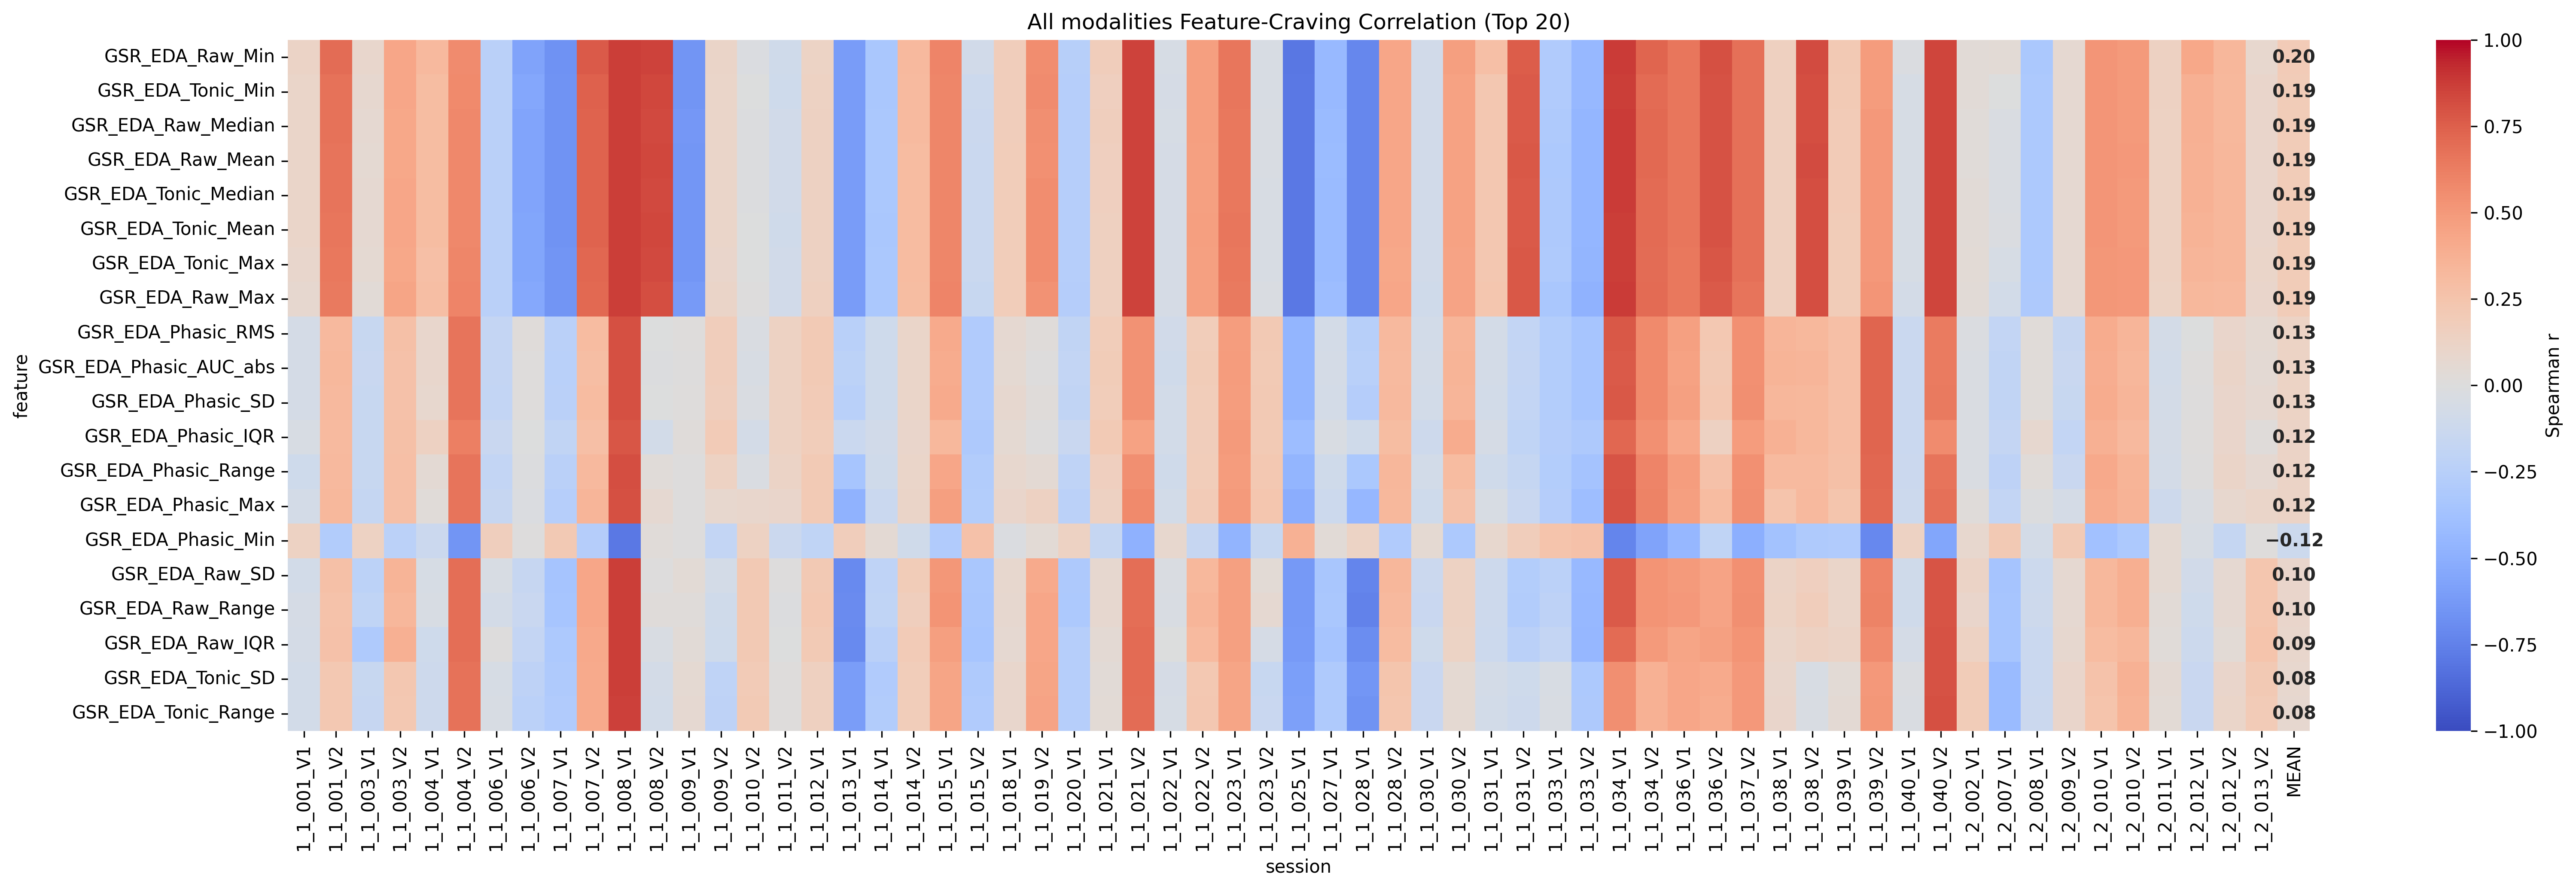

In [8]:
mats = plot_combined_modalities_heatmap(
    corr_csv= RUNS_DIR / "session_feature_correlation_results.csv",
    modalities=("ECG", "PPG", "GSR", "PTT"),
    title = "All modalities Feature-Craving Correlation (Top 20)",
    drop_nan_feature= False,
    drop_nan_session = True,
    top_k=20,
    save_path= RUNS_DIR / "ALL_drop_nan_session_top_20"
)

In [9]:
mats = plot_combined_modalities_heatmap(
    corr_csv=RUNS_DIR / "session_feature_correlation_results.csv",
    modalities=("ECG",),
    title = "ECG Feature-Carving Correlation (Top 30)",
    top_k=30,
    save_path= RUNS_DIR / "ECG_top_30"
)

No features left after dropping incomplete features


In [10]:
mats = plot_combined_modalities_heatmap(
    corr_csv=RUNS_DIR / "session_feature_correlation_results.csv",
    modalities=("PPG",),
    title = "PPG Feature-Carving Correlation (Top 30)",
    agg="median",
    top_k=30,
    save_path= RUNS_DIR / "PPG_top_30"
)

No features left after dropping incomplete features


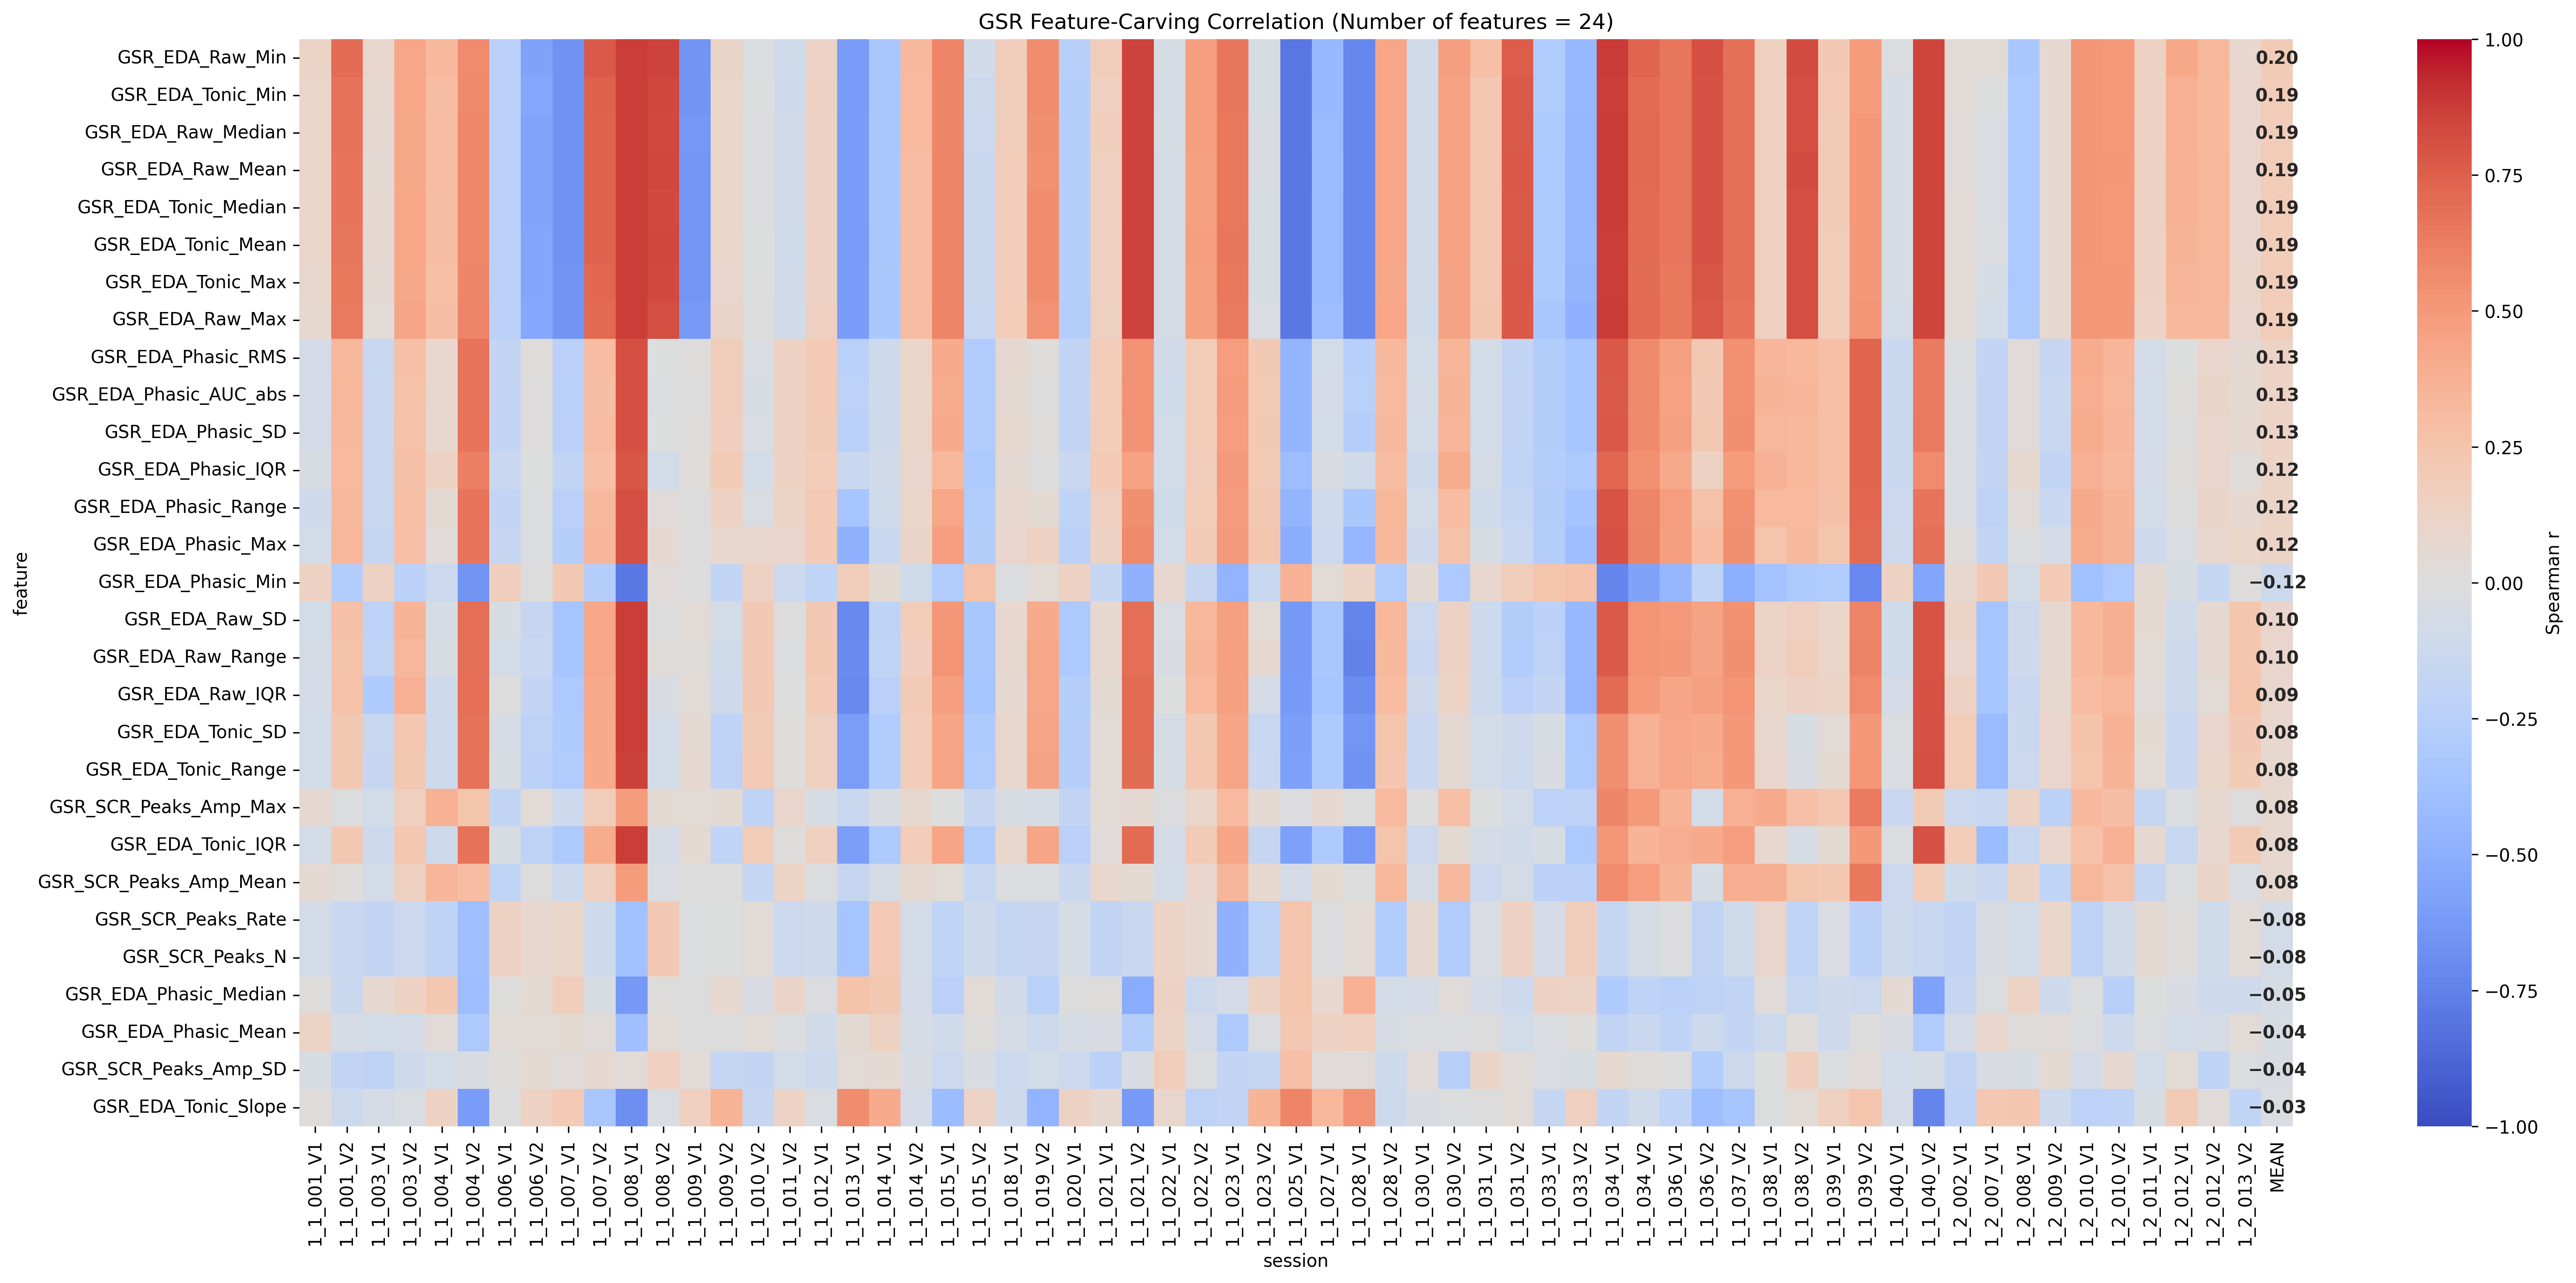

In [11]:
mats = plot_combined_modalities_heatmap(
    corr_csv=RUNS_DIR / "session_feature_correlation_results.csv",
    modalities=("GSR",),
    title = "GSR Feature-Carving Correlation (Number of features = 24)",
    agg="median",
    top_k=30,
    save_path= RUNS_DIR / "GSR_top_30"
)

In [12]:
mats = plot_combined_modalities_heatmap(
    corr_csv=RUNS_DIR / "session_feature_correlation_results.csv",
    modalities=("PTT",),
    title = "PTT Feature-Carving Correlation (number of features = 18)",
    agg="median",
    top_k=30,
    save_path= RUNS_DIR / "GSR_top_30"
)

No features left after dropping incomplete features
